**Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation")

CLINICAL_DIR = PROJECT_ROOT / "05_Results" / "clinical_baselines"
IMAGE_DIR = PROJECT_ROOT / "05_Results" / "image_models"
MULTIMODAL_DIR = PROJECT_ROOT / "05_Results" / "multimodal"

RESULTS_DIR = PROJECT_ROOT / "05_Results" / "final_comparison"
FIGURE_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


**Load results**

In [5]:
clinical_metrics = pd.read_csv(CLINICAL_DIR / "clinical_final_test_metrics.csv")
image_metrics = pd.read_csv(IMAGE_DIR / "final_image_test_metrics.csv")
multimodal_metrics = pd.read_csv(MULTIMODAL_DIR / "final_multimodal_test_metrics.csv")

clinical_preds = pd.read_csv(CLINICAL_DIR / "clinical_test_predictions.csv")
image_preds = pd.read_csv(IMAGE_DIR / "final_image_test_predictions.csv")
multimodal_preds = pd.read_csv(MULTIMODAL_DIR / "final_multimodal_test_predictions.csv")

print("Clinical:", clinical_preds.shape)
print("Image:", image_preds.shape)
print("Multimodal:", multimodal_preds.shape)

Clinical: (317, 7)
Image: (317, 8)
Multimodal: (317, 8)


**Build master metrics table**

In [6]:
comparison = pd.DataFrame([
    {
        "model": "Clinical-only",
        "accuracy": clinical_metrics.loc[0, "accuracy"],
        "precision": clinical_metrics.loc[0, "precision"],
        "recall": clinical_metrics.loc[0, "recall_sensitivity"],
        "specificity": clinical_metrics.loc[0, "specificity"],
        "f1": clinical_metrics.loc[0, "f1"],
        "roc_auc": clinical_metrics.loc[0, "roc_auc"],
        "pr_auc": clinical_metrics.loc[0, "pr_auc"]
    },
    {
        "model": "Image-only",
        "accuracy": image_metrics.loc[0, "accuracy"],
        "precision": image_metrics.loc[0, "precision"],
        "recall": image_metrics.loc[0, "recall"],
        "specificity": image_metrics.loc[0, "specificity"],
        "f1": image_metrics.loc[0, "f1"],
        "roc_auc": image_metrics.loc[0, "roc_auc"],
        "pr_auc": image_metrics.loc[0, "pr_auc"]
    },
    {
        "model": "Multimodal Fusion",
        "accuracy": multimodal_metrics.loc[0, "accuracy"],
        "precision": multimodal_metrics.loc[0, "precision"],
        "recall": multimodal_metrics.loc[0, "recall"],
        "specificity": multimodal_metrics.loc[0, "specificity"],
        "f1": multimodal_metrics.loc[0, "f1"],
        "roc_auc": multimodal_metrics.loc[0, "roc_auc"],
        "pr_auc": multimodal_metrics.loc[0, "pr_auc"]
    }
])

comparison.to_csv(RESULTS_DIR / "final_model_comparison_metrics.csv", index=False)
comparison

,model,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,Clinical-only,0.930599,0.919355,0.960674,0.892086,0.939560,0.981449,0.983615
1,Image-only,0.741325,0.824324,0.685393,0.812950,0.748466,0.828389,0.862808
2,Multimodal Fusion,0.798107,0.851852,0.775281,0.827338,0.811765,0.871696,0.891405


**Metrics bar chart**

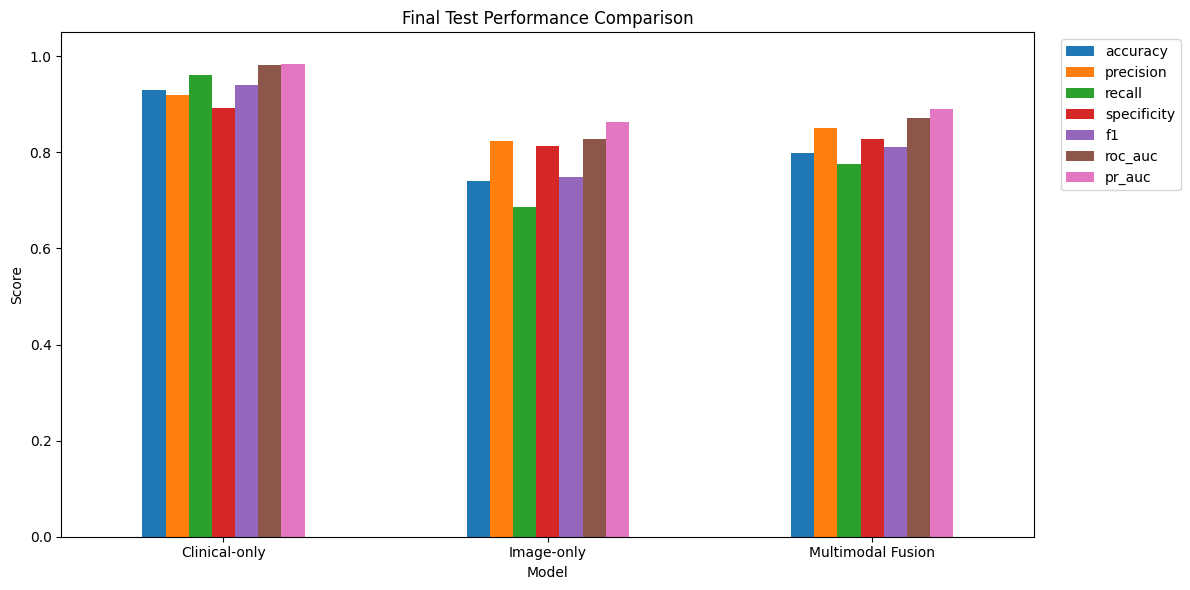

In [7]:
metrics = ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc"]

plot_df = comparison.set_index("model")[metrics]

ax = plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Final Test Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "01_final_metrics_comparison.png", dpi=300)
plt.show()

**ROC curves**

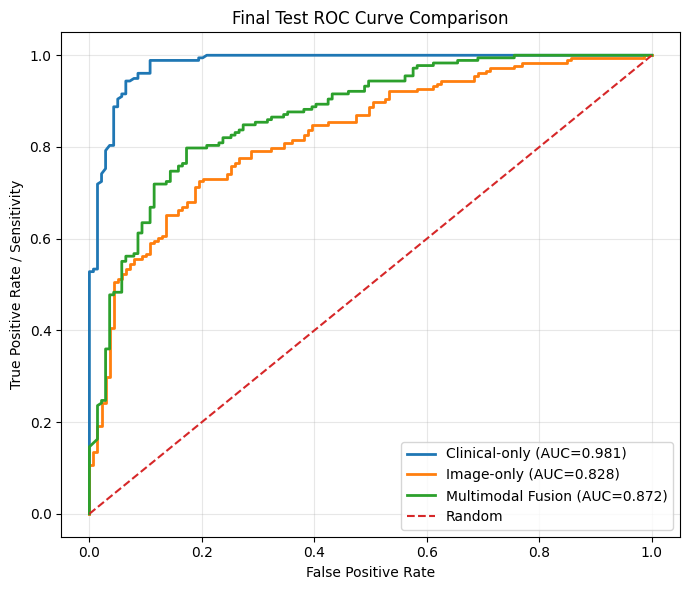

In [8]:
def plot_roc(preds, label):
    y_true = preds["target"].values

    if "malignant_probability" in preds.columns:
        y_prob = preds["malignant_probability"].values
    else:
        y_prob = preds["malignant_probability_x"].values

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")


plt.figure(figsize=(7, 6))

plot_roc(clinical_preds, "Clinical-only")
plot_roc(image_preds, "Image-only")
plot_roc(multimodal_preds, "Multimodal Fusion")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("Final Test ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "02_final_roc_curve_comparison.png", dpi=300)
plt.show()

**Precision-recall curves**

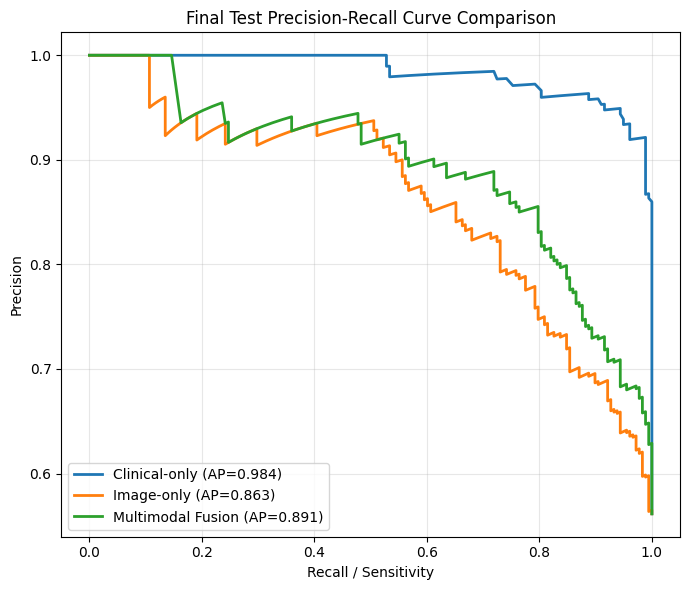

In [9]:
def plot_pr(preds, label):
    y_true = preds["target"].values
    y_prob = preds["malignant_probability"].values

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.plot(recall, precision, linewidth=2, label=f"{label} (AP={ap:.3f})")


plt.figure(figsize=(7, 6))

plot_pr(clinical_preds, "Clinical-only")
plot_pr(image_preds, "Image-only")
plot_pr(multimodal_preds, "Multimodal Fusion")

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Final Test Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "03_final_precision_recall_comparison.png", dpi=300)
plt.show()

**Sensitivity vs specificity**

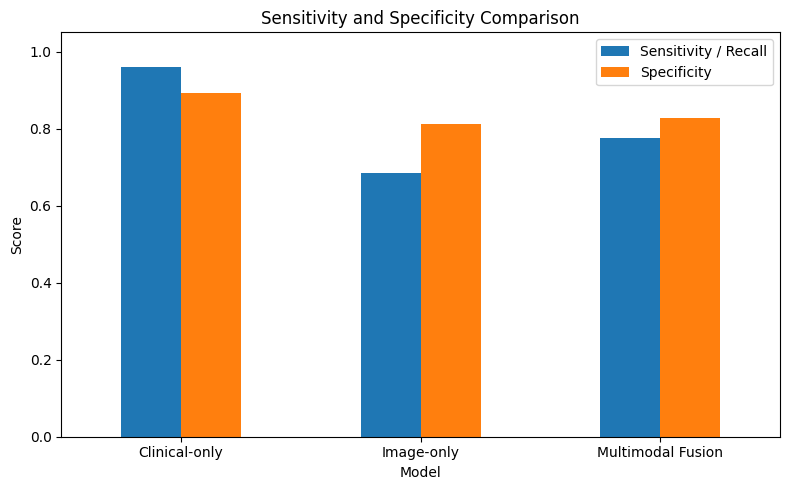

In [10]:
sens_spec = comparison[["model", "recall", "specificity"]].set_index("model")

ax = sens_spec.plot(kind="bar", figsize=(8, 5))

plt.title("Sensitivity and Specificity Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(["Sensitivity / Recall", "Specificity"])
plt.tight_layout()

plt.savefig(FIGURE_DIR / "04_sensitivity_specificity_comparison.png", dpi=300)
plt.show()

**Confusion matrices**

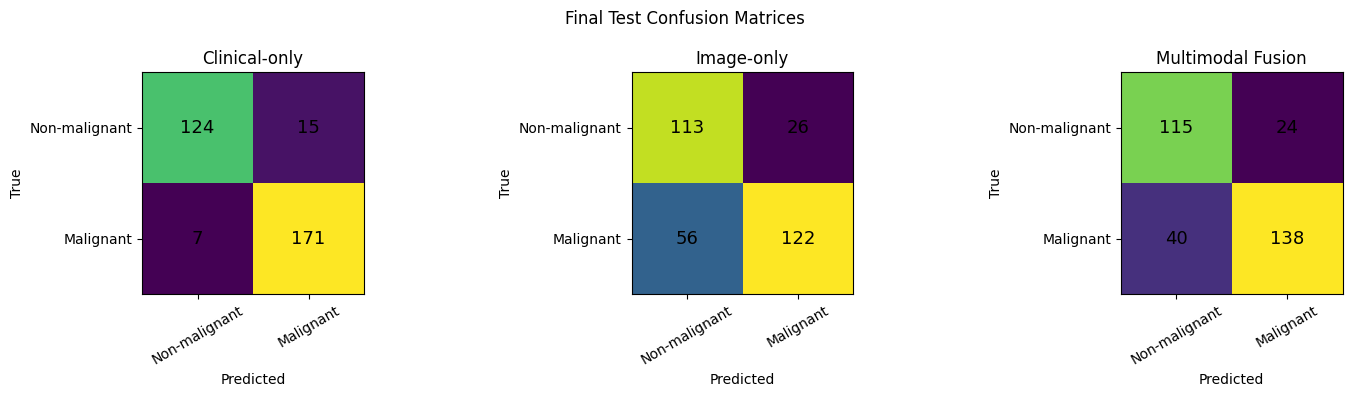

In [11]:
models = [
    ("Clinical-only", clinical_preds),
    ("Image-only", image_preds),
    ("Multimodal Fusion", multimodal_preds)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, models):
    y_true = preds["target"].values
    y_pred = preds["predicted_target"].values if "predicted_target" in preds.columns else preds["prediction"].values

    cm = confusion_matrix(y_true, y_pred)

    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-malignant", "Malignant"], rotation=30)
    ax.set_yticklabels(["Non-malignant", "Malignant"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)

plt.suptitle("Final Test Confusion Matrices")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "05_final_confusion_matrices.png", dpi=300)
plt.show()

**Improvement table**

In [16]:
# ============================================================
# IMPROVEMENT ANALYSIS
# ============================================================

image_row = comparison[
    comparison["model"] == "Image-only"
].iloc[0]

multi_row = comparison[
    comparison["model"] == "Multimodal Fusion"
].iloc[0]

clinical_row = comparison[
    comparison["model"] == "Clinical-only"
].iloc[0]


# Multimodal improvement over image-only
multi_vs_image = {
    "comparison": "Multimodal - Image-only"
}

for metric in metrics:
    multi_vs_image[metric] = (
        multi_row[metric]
        - image_row[metric]
    )


# Clinical-only difference from multimodal
clinical_vs_multi = {
    "comparison": "Clinical-only - Multimodal"
}

for metric in metrics:
    clinical_vs_multi[metric] = (
        clinical_row[metric]
        - multi_row[metric]
    )


# Create final table
improvement = pd.DataFrame([
    multi_vs_image,
    clinical_vs_multi
])


# Convert differences to percentage points
improvement_percentage_points = improvement.copy()

for metric in metrics:
    improvement_percentage_points[metric] = (
        improvement_percentage_points[metric] * 100
    )


# Save both versions
improvement.to_csv(
    RESULTS_DIR / "final_model_improvement_analysis.csv",
    index=False
)

improvement_percentage_points.to_csv(
    RESULTS_DIR / "final_model_improvement_percentage_points.csv",
    index=False
)


print("=" * 75)
print("MODEL IMPROVEMENT ANALYSIS")
print("=" * 75)

display(improvement.round(4))

print("\nDifference in percentage points:")
display(
    improvement_percentage_points.round(2)
)

MODEL IMPROVEMENT ANALYSIS


,comparison,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,Multimodal - Image-only,0.0568,0.0275,0.0899,0.0144,0.0633,0.0433,0.0286
1,Clinical-only - Multimodal,0.1325,0.0675,0.1854,0.0647,0.1278,0.1098,0.0922



Difference in percentage points:


,comparison,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,Multimodal - Image-only,5.68,2.75,8.99,1.44,6.33,4.33,2.86
1,Clinical-only - Multimodal,13.25,6.75,18.54,6.47,12.78,10.98,9.22


**Save figure index**

In [17]:
figure_index = pd.DataFrame({
    "figure_number": [1, 2, 3, 4, 5],
    "figure": [
        "Final Metrics Comparison",
        "Final ROC Curve Comparison",
        "Final Precision-Recall Curve Comparison",
        "Sensitivity and Specificity Comparison",
        "Final Confusion Matrices"
    ],
    "filename": [
        "01_final_metrics_comparison.png",
        "02_final_roc_curve_comparison.png",
        "03_final_precision_recall_comparison.png",
        "04_sensitivity_specificity_comparison.png",
        "05_final_confusion_matrices.png"
    ]
})

figure_index.to_csv(FIGURE_DIR / "final_comparison_figure_index.csv", index=False)

print("Final comparison complete.")
print("Saved to:", FIGURE_DIR)

Final comparison complete.
Saved to: /content/drive/MyDrive/Dissertation/05_Results/final_comparison/figures
